In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import classification_report, confusion_matrix

dataset = pd.read_csv(r"C:\Users\healk\Desktop\PROJECT_LEAVERS\card_transdata.csv") 
dataset.head()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,57.877857,0.311140,1.945940,1.0,1.0,0.0,0.0,0.0
1,10.829943,0.175592,1.294219,1.0,0.0,0.0,0.0,0.0
2,5.091079,0.805153,0.427715,1.0,0.0,0.0,1.0,0.0
3,2.247564,5.600044,0.362663,1.0,1.0,0.0,1.0,0.0
4,44.190936,0.566486,2.222767,1.0,1.0,0.0,1.0,0.0


This dataset is **not** generated by deep learning model, its sourced by some unnamed institute, probably some private company data.

Feature Explanation:

distance_from_home - the distance from home where the transaction happened.

distance_from_last_transaction - the distance from last transaction happened.

ratio_to_median_purchase_price - Ratio of purchased price transaction to median purchase price.

repeat_retailer - Is the transaction happened from same retailer.

used_chip - Is the transaction through chip (credit card).

used_pin_number - Is the transaction happened by using PIN number.

online_order - Is the transaction an online order.

fraud - Is the transaction fraudulent.

In [3]:
dataset.dtypes

distance_from_home                float64
distance_from_last_transaction    float64
ratio_to_median_purchase_price    float64
repeat_retailer                   float64
used_chip                         float64
used_pin_number                   float64
online_order                      float64
fraud                             float64
dtype: object

We are having with 3 numeric and 5 flags columns, including target column (binary classification)

In [5]:
for col in dataset.columns:
    pct_missing = np.mean(dataset[col].isnull())
    print(col, f'{pct_missing * 100}%')

print(len(dataset))

distance_from_home 0.0%
distance_from_last_transaction 0.0%
ratio_to_median_purchase_price 0.0%
repeat_retailer 0.0%
used_chip 0.0%
used_pin_number 0.0%
online_order 0.0%
fraud 0.0%
1000000


In [6]:
dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
distance_from_home,1000000.0,26.628792,65.390784,0.004874,3.878008,9.967760,25.743985,10632.723672
distance_from_last_transaction,1000000.0,5.036519,25.843093,0.000118,0.296671,0.998650,3.355748,11851.104565
ratio_to_median_purchase_price,1000000.0,1.824182,2.799589,0.004399,0.475673,0.997717,2.096370,267.802942
repeat_retailer,1000000.0,0.881536,0.323157,0.000000,1.000000,1.000000,1.000000,1.000000
used_chip,1000000.0,0.350399,0.477095,0.000000,0.000000,0.000000,1.000000,1.000000
used_pin_number,1000000.0,0.100608,0.300809,0.000000,0.000000,0.000000,0.000000,1.000000
online_order,1000000.0,0.650552,0.476796,0.000000,0.000000,1.000000,1.000000,1.000000
fraud,1000000.0,0.087403,0.282425,0.000000,0.000000,0.000000,0.000000,1.000000


# EDA


fraud
0.0    91.2597
1.0     8.7403
Name: count, dtype: float64%


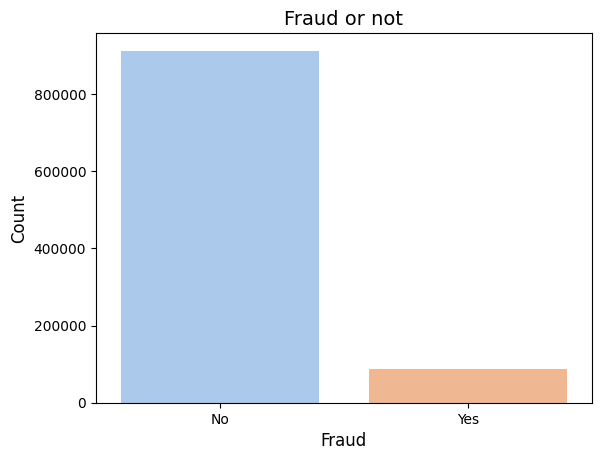

In [8]:
target = dataset['fraud']

sns.countplot(x=target.replace({0: "No", 1: "Yes"}), hue = target.replace({0: "No", 1: "Yes"}), palette='pastel', legend=False)
plt.title('Fraud or not', fontsize=14)
plt.xlabel('Fraud', fontsize=12)
plt.ylabel('Count', fontsize=12)

target_counts = target.value_counts()
print(f'{target_counts / len(dataset) * 100}%') 

We are dealing with highly disbalanced classes.

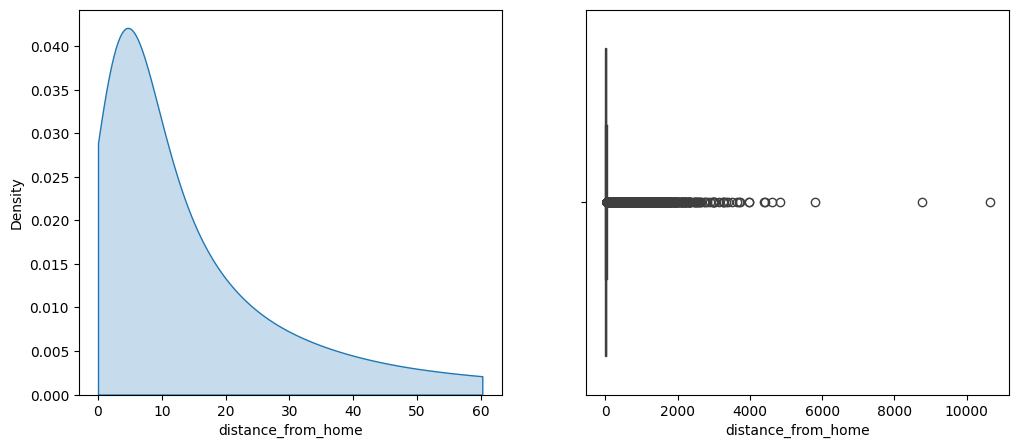

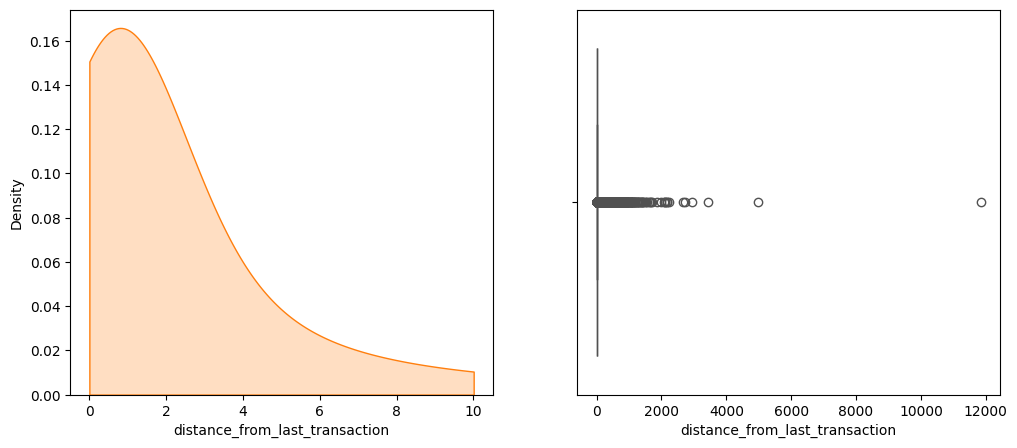

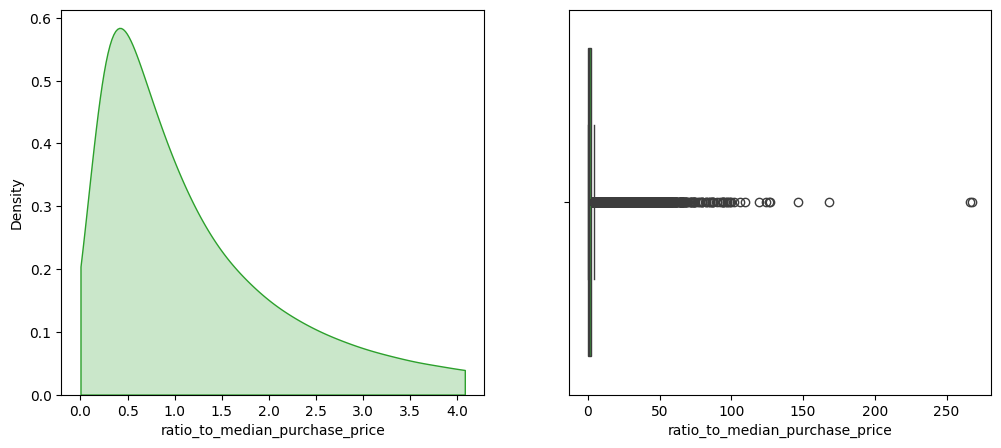

In [10]:
dataset_numerical = dataset[['distance_from_home','distance_from_last_transaction','ratio_to_median_purchase_price']]
dataset_boolean = dataset[[col for col in dataset.columns if dataset[col].nunique() == 2]] 

numerical_cols = dataset_numerical.columns
boolean_cols = dataset_boolean.columns

palette = sns.color_palette('tab10', len(numerical_cols))
color_dict = dict(zip(numerical_cols, palette))

for col in numerical_cols:
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    sns.kdeplot(data=dataset_numerical, x=col, color=color_dict[col], fill=True, clip=(0, dataset_numerical[col].quantile(0.9)), ax = ax[0])
    
    sns.boxplot(data=dataset_numerical, x=col, color=color_dict[col], ax=ax[1])

We are having enormous amount of outliners, lets check if we can get rid of them

In [12]:
def remove_outliers_iqr(dataframe, column):
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    filtered_df = dataframe[(dataframe[column] >= lower_bound) & (dataframe[column] <= upper_bound)]
    return filtered_df

dataset_new = dataset.copy()
for col in numerical_cols:
    dataset_new = remove_outliers_iqr(dataset_new, col)

fraud
0.0    98.748828
1.0     1.251172
Name: count, dtype: float64%


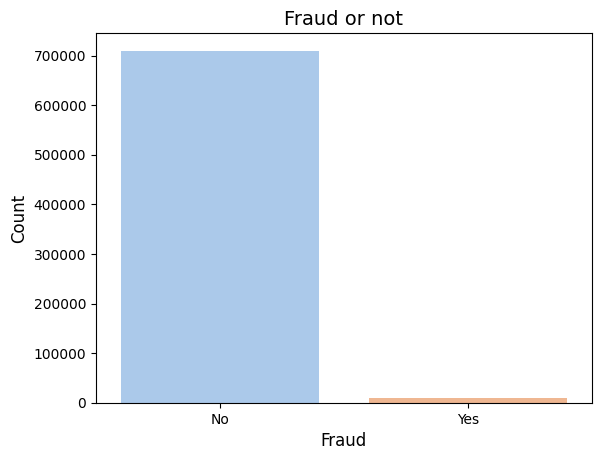

In [13]:
target2 = dataset_new['fraud']

sns.countplot(x=target2.replace({0: "No", 1: "Yes"}), hue = target2.replace({0: "No", 1: "Yes"}), palette='pastel', legend=False)
plt.title('Fraud or not', fontsize=14)
plt.xlabel('Fraud', fontsize=12)
plt.ylabel('Count', fontsize=12)

target2_counts = target2.value_counts()
print(f'{target2_counts / len(dataset_new) * 100}%') 

as a result, we should not erase the outliners since class proportion is completely different and there is also lack of sample

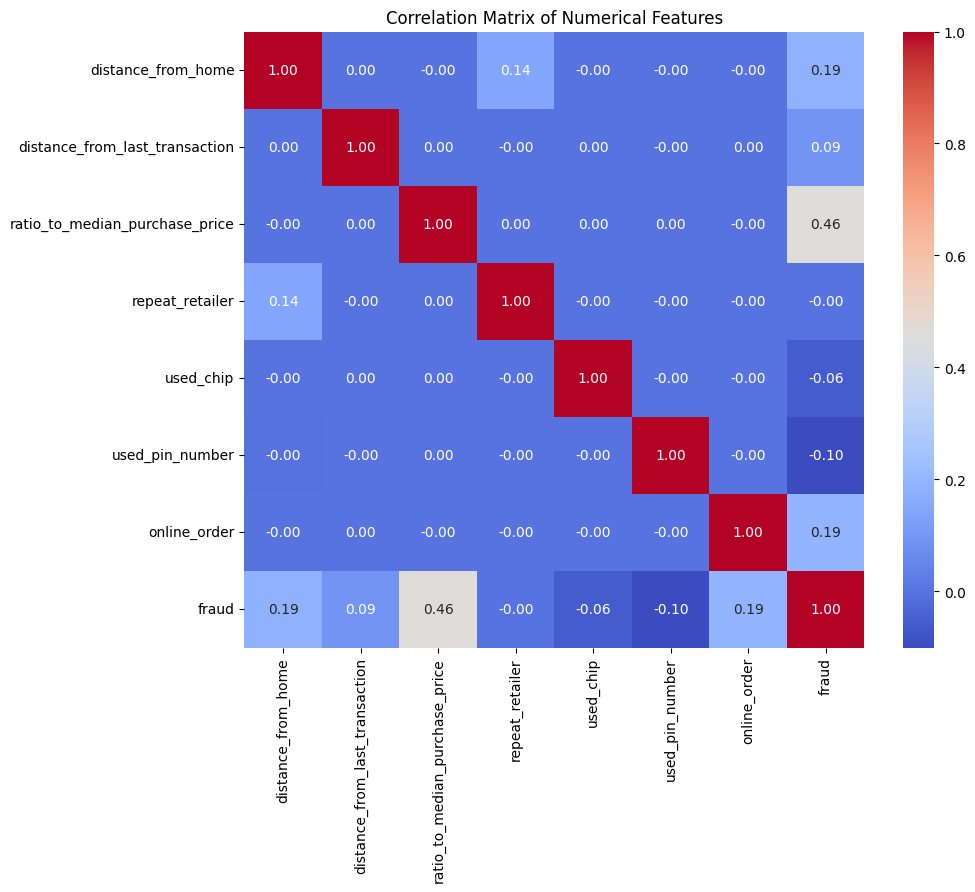

In [15]:
correlation_matrix = dataset.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Numerical Features")
plt.show()

Looks like ratio_to_median_purchase_price has significant impact on fraudulance

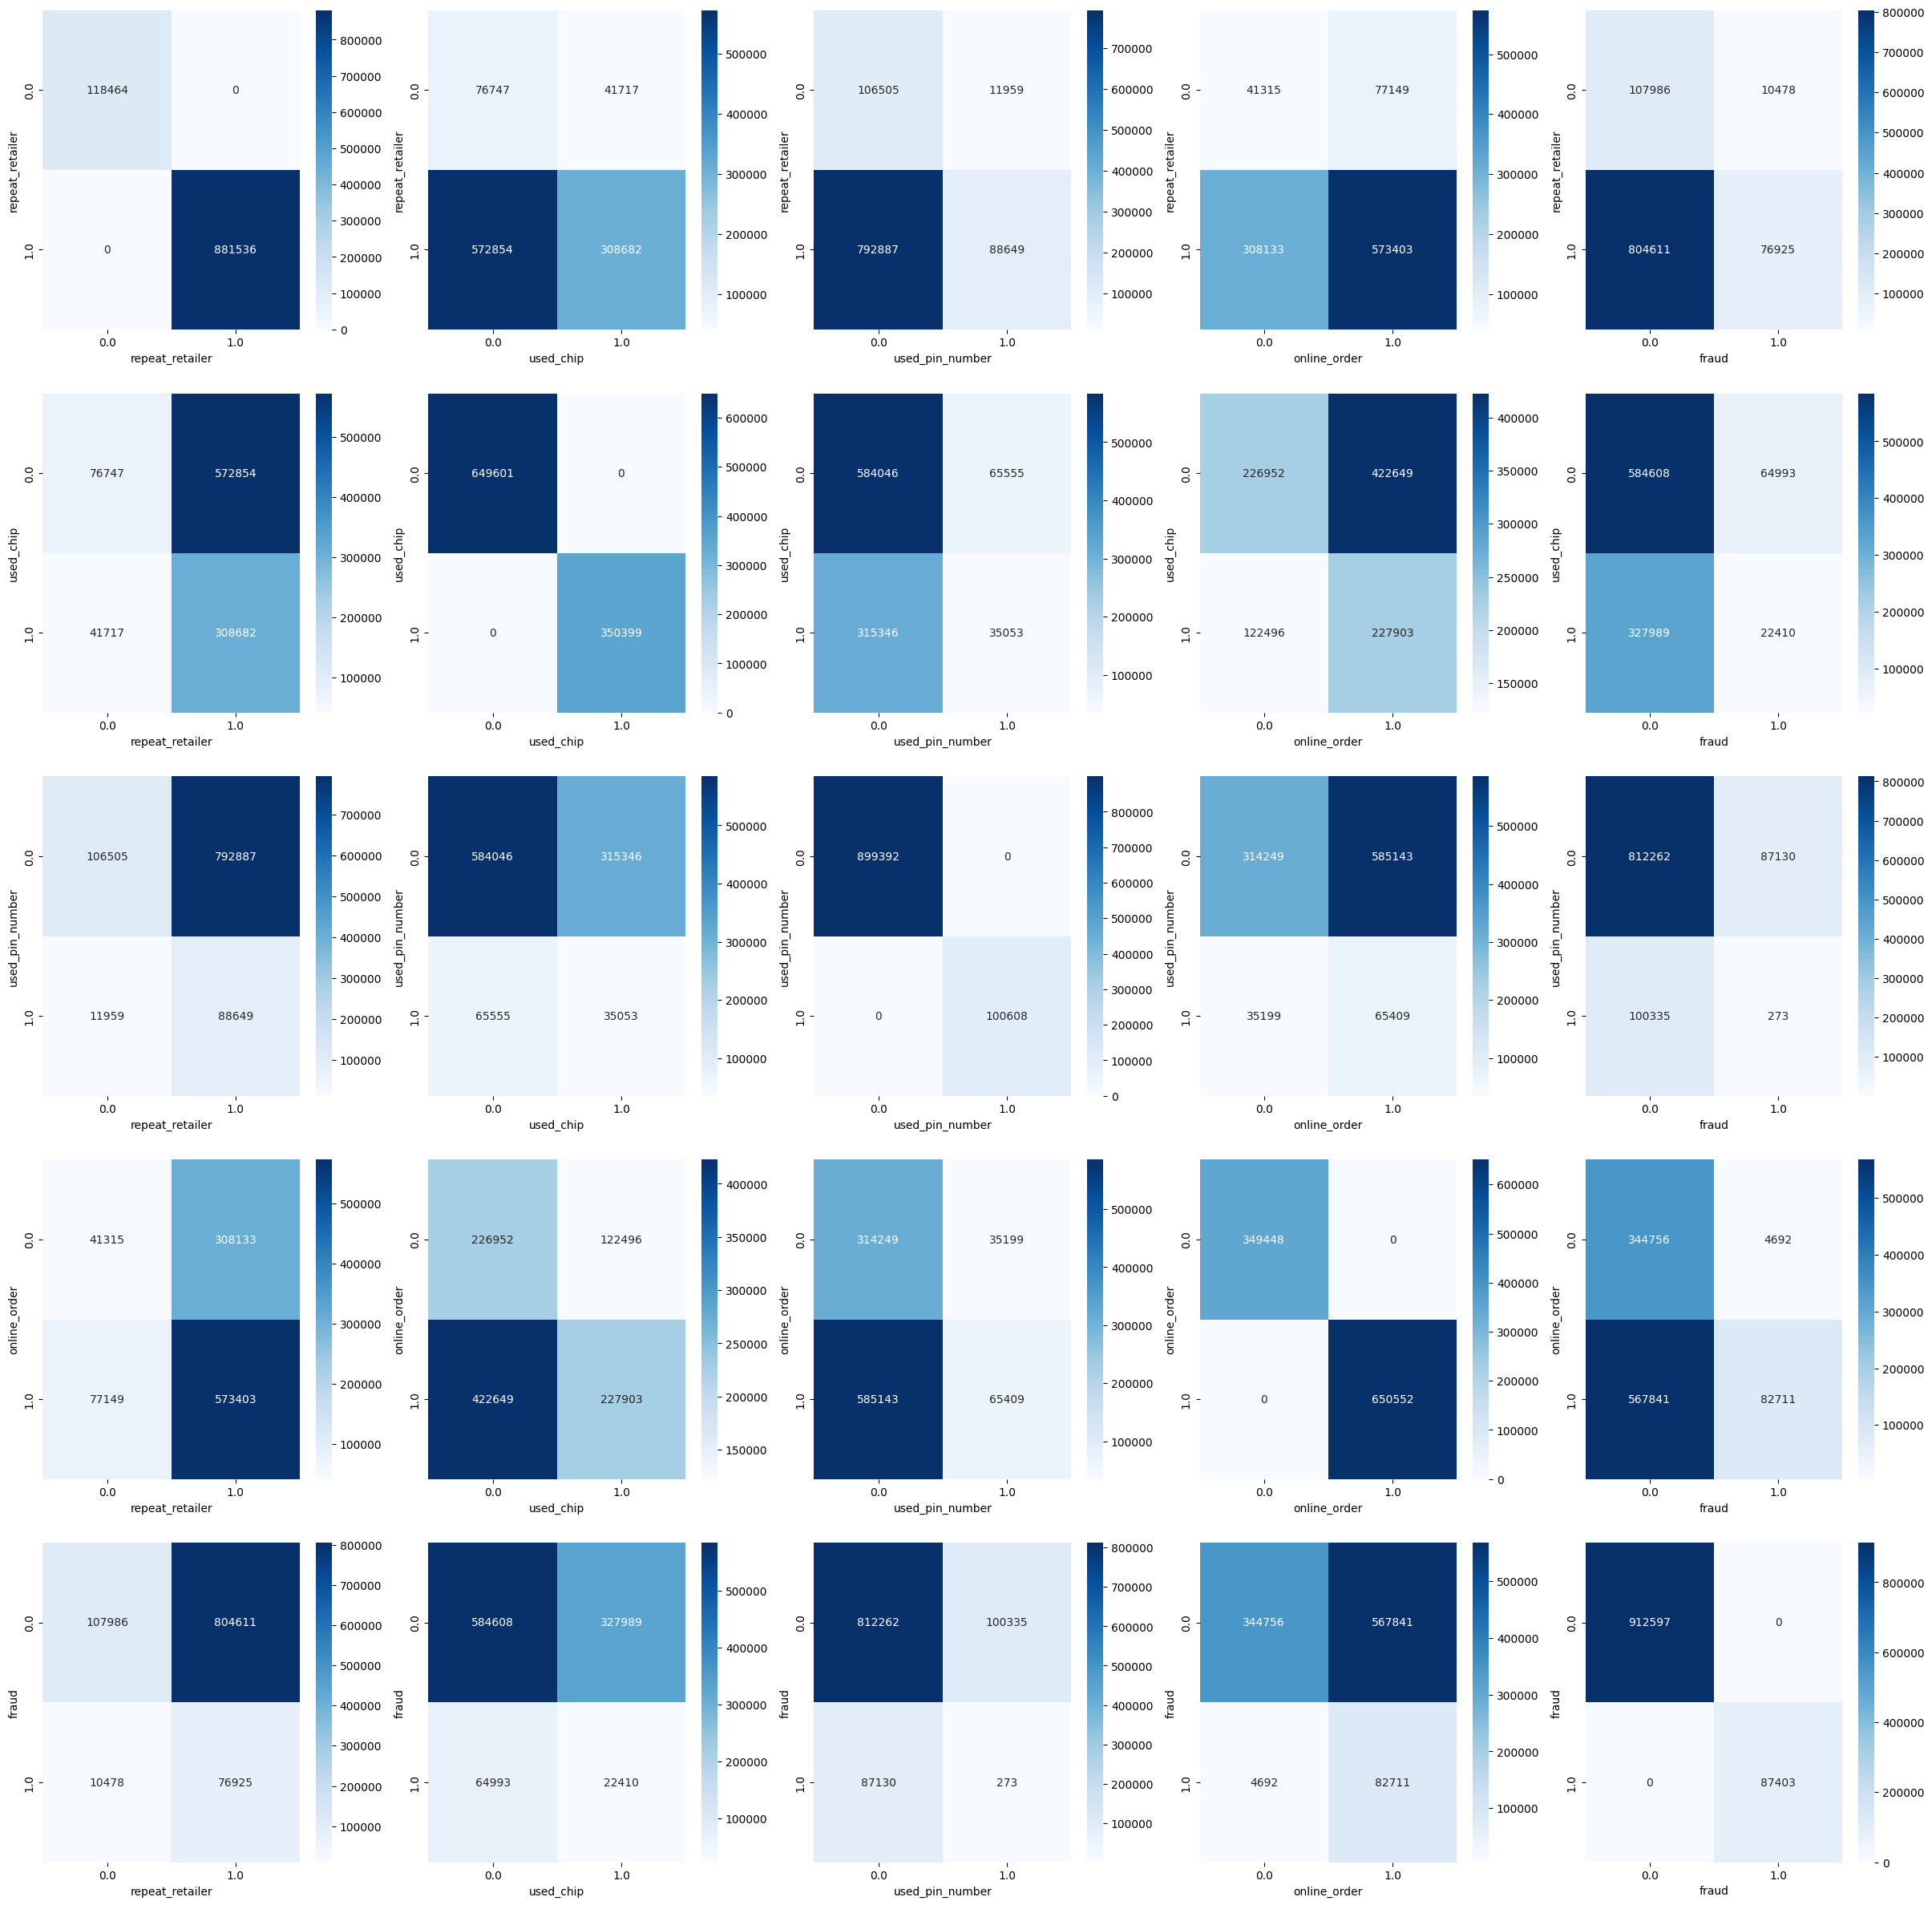

In [17]:
fig, axes = plt.subplots(5, 5, figsize=(30, 30))
for i in range(len(boolean_cols)):
    for j in range(len(boolean_cols)):       
        heatmap_data = dataset_boolean.groupby([dataset_boolean.iloc[:, i], dataset_boolean.iloc[:, j]]).size().unstack(fill_value=0).astype(int)
        sns.heatmap(heatmap_data, annot=True, fmt="d", cmap="Blues", cbar=True, ax = axes[i, j])


+ almost all fraud operations are made by not using pin
+ almost all fraud operations are online
+ other features seem to have no connection

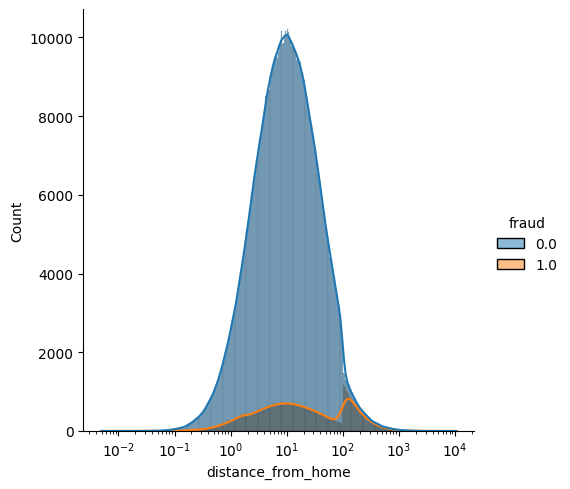

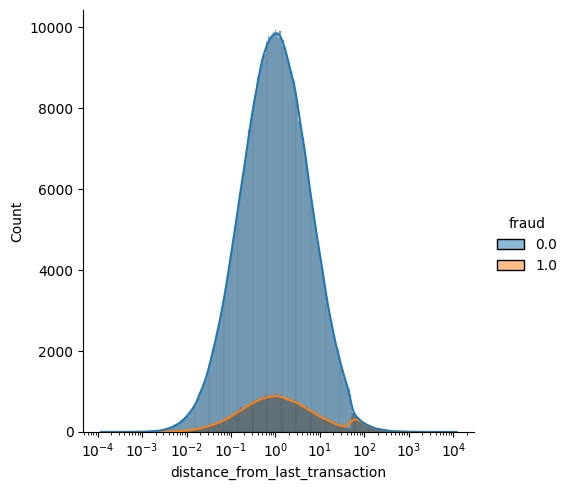

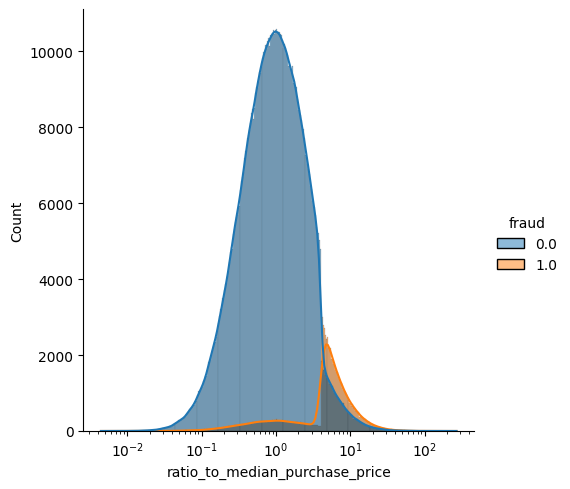

In [19]:

for i in range(3):
    sns.displot(data=dataset, x=dataset_numerical.iloc[:, i], hue='fraud', log_scale=True, kde=True)


Obvious difference in distributions between classes, so we need to highlight it in feature engineering

# Feature Engineering 

In [22]:
# 'distance_from_home','distance_from_last_transaction','ratio_to_median_purchase_price' distance_from_home                float64
#distance_from_last_transaction    float64
#ratio_to_median_purchase_price    float64
#repeat_retailer                   float64
#used_chip                         float64
#used_pin_number                   float64
#online_order                      float64
#fraud                             float64
def feature_engineering(df):
    df['distance_from_home_anomaly'] = (df['distance_from_home'] > 75).astype(int)
    df['distance_from_last_transaction_anomaly'] = (df['distance_from_last_transaction'] > 25).astype(int)
    df['ratio_to_median_purchase_price_anomaly'] = (df['ratio_to_median_purchase_price'] > 4).astype(int)
#    df['no_pin_distance_from_home'] = df['used_pin_number'] * df['distance_from_home']
#    df['no_pin_distance_from_last_transaction'] = df['used_pin_number'] * df['distance_from_last_transaction']
#    df['no_pin_ratio_to_median_purchase_price'] = df['used_pin_number'] * df['ratio_to_median_purchase_price']
#    df['online_distance_from_home'] = (1 - df['online_order']) * df['distance_from_home']
#    df['online_distance_from_last_transaction'] = (1- df['online_order']) * df['distance_from_last_transaction']
#    df['online_ratio_to_median_purchase_price'] = (1- df['online_order']) * df['ratio_to_median_purchase_price'] 

# OPTIONS THAT COULD BE TRIED
    
    df['online_and_no_pin'] = ((df['online_order'] == 1) & (df['used_pin_number'] == 0)).astype(int)

#    df_numerical = df[['distance_from_home', 'distance_from_last_transaction', 'ratio_to_median_purchase_price']]
#    scaler = StandardScaler()
#    scaled_values = scaler.fit_transform(df_numerical)
#    df[['distance_from_home', 'distance_from_last_transaction', 'ratio_to_median_purchase_price']] = scaled_values

# STANDART SCALING CAN BE ACTIVATED BUT SHOWED NO DIFFERENCE LATER 

    return df

dataset = feature_engineering(dataset)
dataset.head()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud,distance_from_home_anomaly,distance_from_last_transaction_anomaly,ratio_to_median_purchase_price_anomaly,online_and_no_pin
0,57.877857,0.311140,1.945940,1.0,1.0,0.0,0.0,0.0,0,0,0,0
1,10.829943,0.175592,1.294219,1.0,0.0,0.0,0.0,0.0,0,0,0,0
2,5.091079,0.805153,0.427715,1.0,0.0,0.0,1.0,0.0,0,0,0,1
3,2.247564,5.600044,0.362663,1.0,1.0,0.0,1.0,0.0,0,0,0,1
4,44.190936,0.566486,2.222767,1.0,1.0,0.0,1.0,0.0,0,0,0,1


highlited anomalies + online and no pin could be useful based on EDA

(0.0, 10.0)

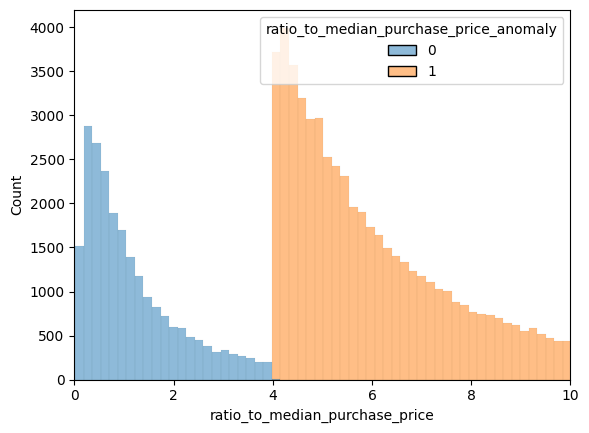

In [24]:
sns.histplot(data=dataset[dataset['fraud']==1], x='ratio_to_median_purchase_price', hue='ratio_to_median_purchase_price_anomaly')
plt.xlim(0, 10)


this plot was used to pick values for selecting anomalies. It highlites 2 different distributions 

<Axes: xlabel='ratio_to_median_purchase_price_anomaly', ylabel='fraud'>

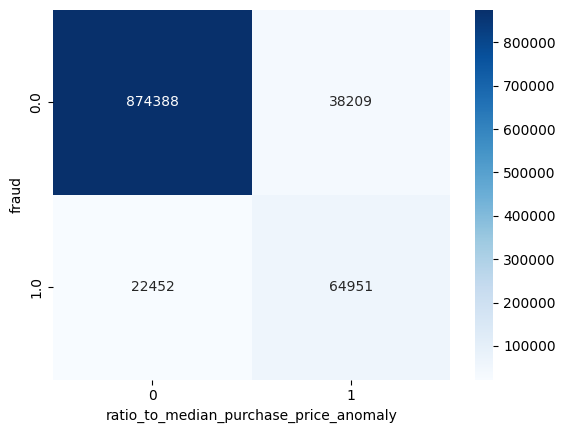

In [26]:
heatmap_data = dataset.groupby(['fraud', 'ratio_to_median_purchase_price_anomaly']).size().unstack(fill_value=0).astype(int)
sns.heatmap(heatmap_data, annot=True, fmt="d", cmap="Blues", cbar=True)

from this plot we see that 5% of usual operations and 75% of fraud operations satisfy critetion, so it accomplished its purpose.

# Model Training and results 


In [29]:
dataset.head()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud,distance_from_home_anomaly,distance_from_last_transaction_anomaly,ratio_to_median_purchase_price_anomaly,online_and_no_pin
0,57.877857,0.311140,1.945940,1.0,1.0,0.0,0.0,0.0,0,0,0,0
1,10.829943,0.175592,1.294219,1.0,0.0,0.0,0.0,0.0,0,0,0,0
2,5.091079,0.805153,0.427715,1.0,0.0,0.0,1.0,0.0,0,0,0,1
3,2.247564,5.600044,0.362663,1.0,1.0,0.0,1.0,0.0,0,0,0,1
4,44.190936,0.566486,2.222767,1.0,1.0,0.0,1.0,0.0,0,0,0,1


In [30]:
dataset = dataset.drop(['fraud'], axis=1)

In [31]:
x_train,x_test,y_train,y_test=train_test_split(dataset,target,train_size=0.80,random_state=42)
print(f'{len(y_train[y_train == 1]) / len(y_train[y_train == 0]) * 100}% in train set')
print(f'{len(y_test[y_test == 1]) / len(y_test[y_test == 0]) * 100}% in train set')

9.583036545942688% in train set
9.554823972786581% in train set


In [32]:

model = DecisionTreeClassifier(random_state=42, class_weight='balanced')
model.fit(x_train, y_train)

train_pred = model.predict(x_train)
test_pred = model.predict(x_test)

print("Train Set Evaluation:")
print(confusion_matrix(y_train, train_pred))
print(classification_report(y_train, train_pred))

print("Test Set Evaluation:")
print(confusion_matrix(y_test, test_pred))
print(classification_report(y_test, test_pred))

Train Set Evaluation:
[[730040      0]
 [     0  69960]]
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    730040
         1.0       1.00      1.00      1.00     69960

    accuracy                           1.00    800000
   macro avg       1.00      1.00      1.00    800000
weighted avg       1.00      1.00      1.00    800000

Test Set Evaluation:
[[182555      2]
 [     0  17443]]
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    182557
         1.0       1.00      1.00      1.00     17443

    accuracy                           1.00    200000
   macro avg       1.00      1.00      1.00    200000
weighted avg       1.00      1.00      1.00    200000



Text(120.72222222222221, 0.5, 'Truth')

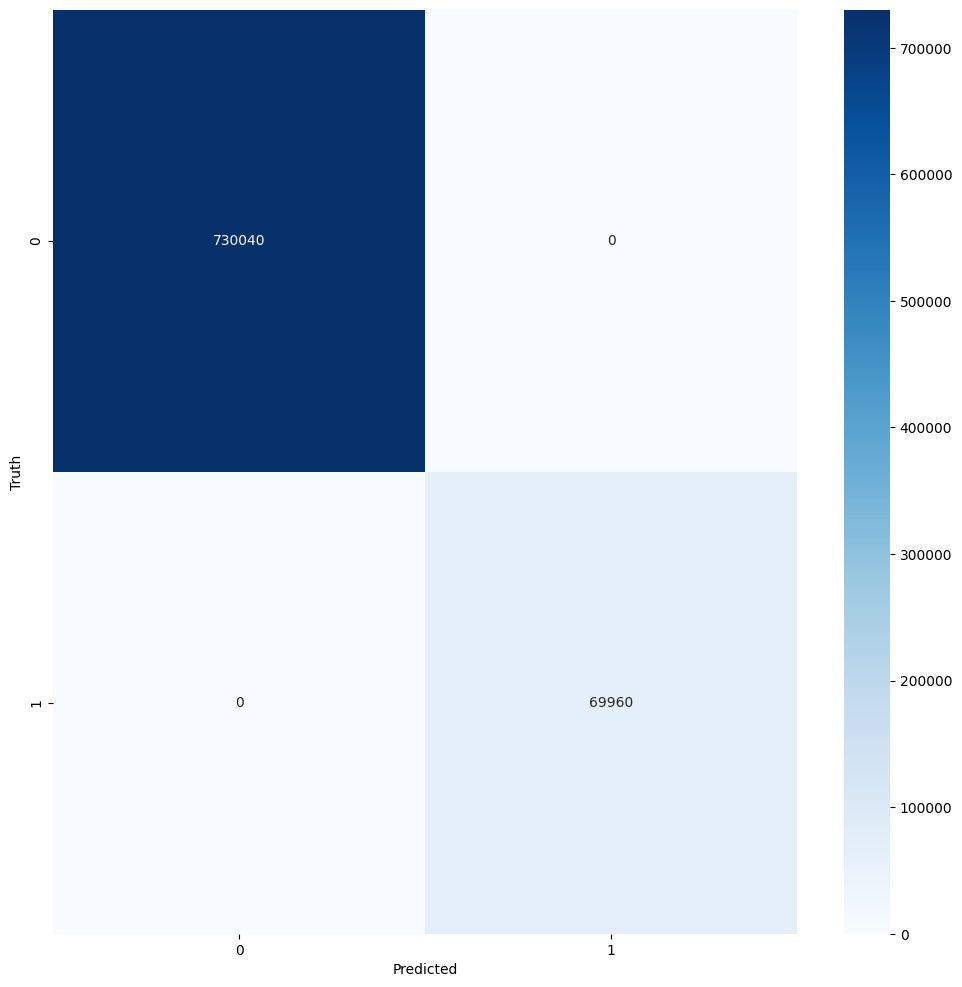

In [33]:
plt.figure(figsize = (12, 12))

sns.heatmap(confusion_matrix(y_train, train_pred), annot = True, fmt=".0f", cmap = "Blues")
plt.xlabel("Predicted")
plt.ylabel("Truth")

Text(120.72222222222221, 0.5, 'Truth')

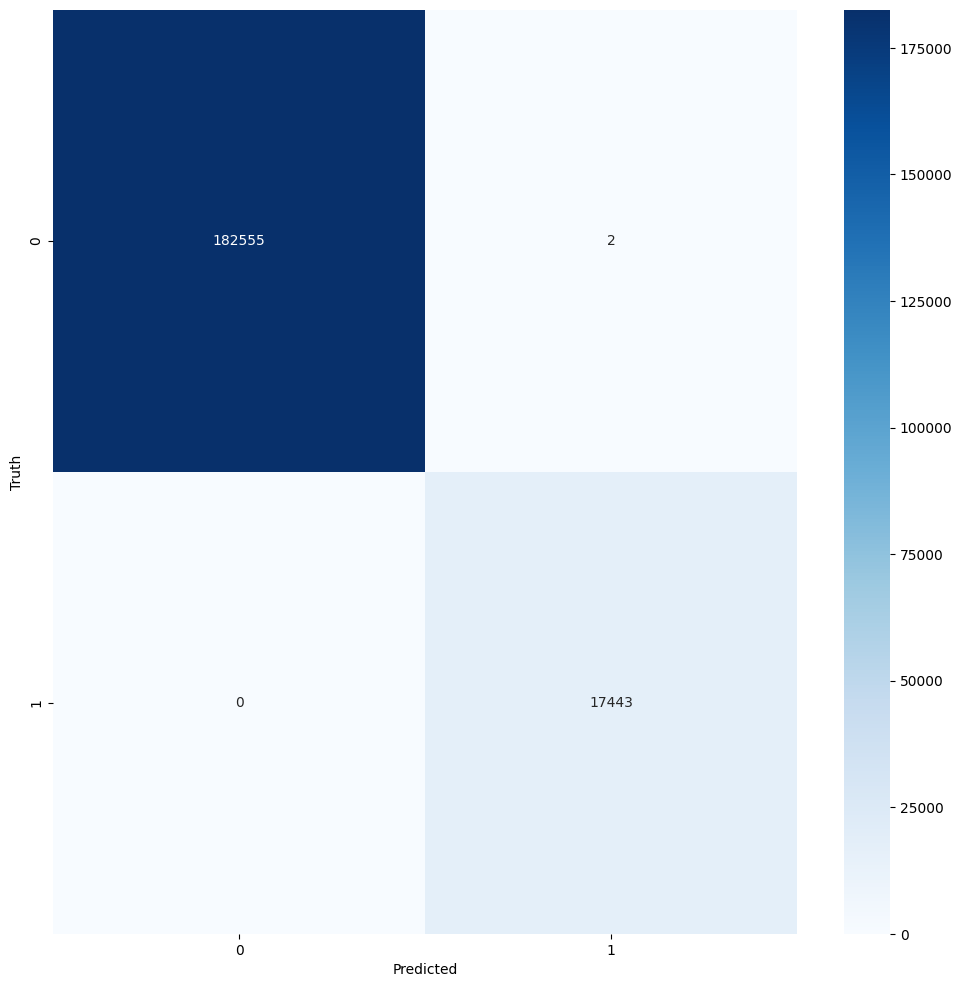

In [34]:
plt.figure(figsize = (12, 12))

sns.heatmap(confusion_matrix(y_test, test_pred), annot = True, fmt=".0f", cmap = "Blues")
plt.xlabel("Predicted")
plt.ylabel("Truth")

As a result, simple decision tree model solved this task literally perfect and is not overfitting. At first sight it might seem suspicious and i spend some time to check data leakage / other code mistakes, but after reading some works on kaggle i came to conclusion that this result is normal for this exact dataset. Some ideas why this happened:
+ Dataset is not really human made as it was stated
+ There is exact mathematical formula to calculate fraudulance

We can check last option using plot_tree function from sklearn

In [36]:
print(export_text(model, feature_names=dataset.columns))


|--- ratio_to_median_purchase_price <= 4.00
|   |--- distance_from_home <= 100.00
|   |   |--- distance_from_last_transaction <= 50.00
|   |   |   |--- class: 0.0
|   |   |--- distance_from_last_transaction >  50.00
|   |   |   |--- online_and_no_pin <= 0.50
|   |   |   |   |--- class: 0.0
|   |   |   |--- online_and_no_pin >  0.50
|   |   |   |   |--- used_chip <= 0.50
|   |   |   |   |   |--- class: 1.0
|   |   |   |   |--- used_chip >  0.50
|   |   |   |   |   |--- repeat_retailer <= 0.50
|   |   |   |   |   |   |--- class: 1.0
|   |   |   |   |   |--- repeat_retailer >  0.50
|   |   |   |   |   |   |--- class: 0.0
|   |--- distance_from_home >  100.00
|   |   |--- online_and_no_pin <= 0.50
|   |   |   |--- distance_from_last_transaction <= 50.24
|   |   |   |   |--- class: 0.0
|   |   |   |--- distance_from_last_transaction >  50.24
|   |   |   |   |--- used_pin_number <= 0.50
|   |   |   |   |   |--- class: 1.0
|   |   |   |   |--- used_pin_number >  0.50
|   |   |   |   |   |--- 

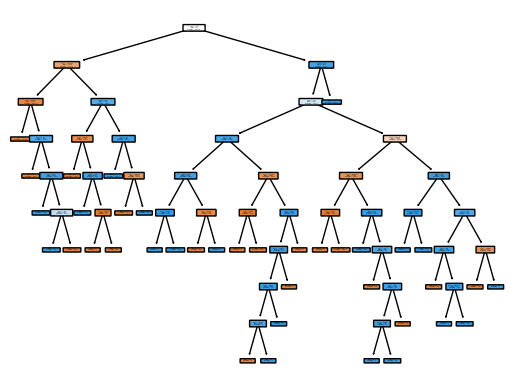

In [37]:
plot_tree(model, filled=True, rounded=True)
plt.show()

As our model is nearly perfect we can highlight 2 most simple options with depth of 2 and 3:

+ ratio_to_median_purchase_price <= 4, distance_from_home <= 100, distance_from_last_transaction <= 50

+ ratio_to_median_purchase_price > 4, online_and_no_pin = 1

And from these exact options its clearly seen that this weird distribution difference starting from ratio_to_median_purchase_price = 4 has significant impact on model.